In [67]:
#IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from statsmodels.tsa.stattools import adfuller

In [68]:
#load data
df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

In [69]:
print(df.head())
print(df.info())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [70]:
#  CREATE DATE COLUMN
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

df = df.sort_values("Date")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01



Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64

Summary Statistics
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   
std       3.1

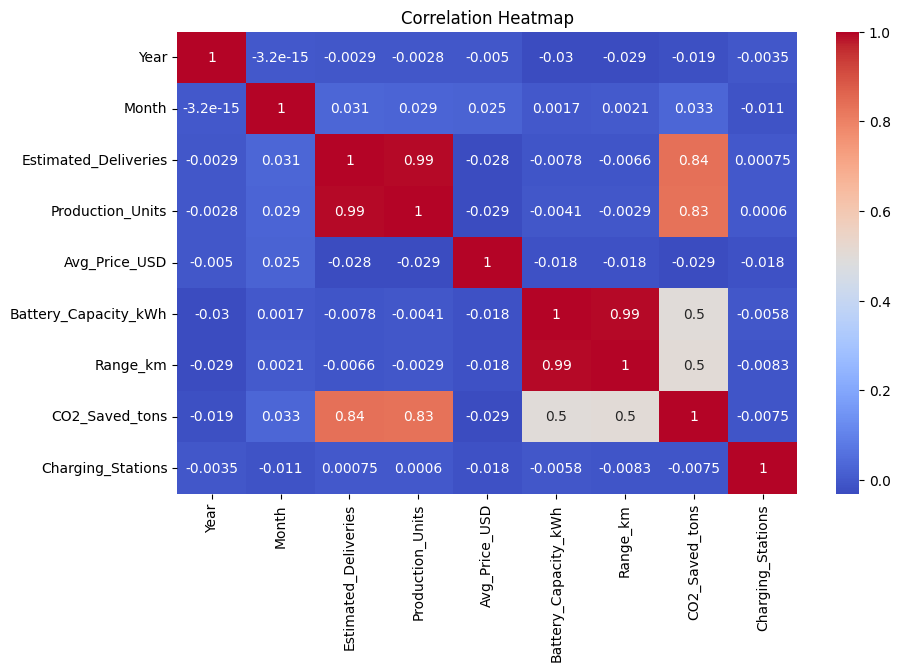

In [71]:
# EDA

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
print(df.describe())

plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [72]:
# FEATURE ENGINEERING
df['Lag_1'] = df['Estimated_Deliveries'].shift(1)
df['Lag_2'] = df['Estimated_Deliveries'].shift(2)

df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df.dropna(inplace=True)


In [73]:
# STATIONARITY TEST

print("\nADF Test")

adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", adf_result[0])
print("P-Value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary")



ADF Test
ADF Statistic: -28.16348539815911
P-Value: 0.0
Series is Stationary


In [74]:
# FEATURES AND TARGET

target = 'Estimated_Deliveries'

features = [
    'Year',
    'Month',
    'Region',
    'Model',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Lag_1',
    'Lag_2',
    'Rolling_Mean_3'
]

X = df[features]
y = df[target]

In [75]:
# CHRONOLOGICAL SPLIT

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTrain Size:", len(X_train))
print("Test Size:", len(X_test))



Train Size: 2110
Test Size: 528


In [76]:
# PREPROCESSING PIPELINE

categorical_features = ['Region', 'Model']

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])


In [77]:
# LINEAR REGRESSION

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

print("\n LINEAR REGRESSION ")
print("MAE :", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R2  :", r2_score(y_test, linear_pred))



 LINEAR REGRESSION 
MAE : 6.3130645492382236e-12
RMSE: 7.753873710285213e-12
R2  : 1.0


In [78]:
# RIDGE REGRESSION + HYPERPARAMETER TUNING


ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

tscv = TimeSeriesSplit(n_splits=5)

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

ridge_pred = ridge_grid.predict(X_test)

print("\n RIDGE REGRESSION")
print("Best Alpha:", ridge_grid.best_params_)

print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2  :", r2_score(y_test, ridge_pred))


 RIDGE REGRESSION
Best Alpha: {'model__alpha': 0.01}
MAE : 0.819836793457491
RMSE: 0.9970038927941524
R2  : 0.999999925236788


In [79]:
# 12. LASSO REGRESSION
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

lasso_pred = lasso_grid.predict(X_test)

print("\n LASSO REGRESSION ")
print("Best Alpha:", lasso_grid.best_params_)

print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2  :", r2_score(y_test, lasso_pred))



 LASSO REGRESSION 
Best Alpha: {'model__alpha': 0.01}
MAE : 9.855361869896093
RMSE: 11.987985078722799
R2  : 0.9999891909722838


In [80]:
# MODEL COMPARISON


results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'R2': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ]
})

print("\nMODEL COMPARISON")
print(results.sort_values(by='R2', ascending=False))


MODEL COMPARISON
               Model        R2          RMSE
0  Linear Regression  1.000000  7.753874e-12
1   Ridge Regression  1.000000  9.970039e-01
2   Lasso Regression  0.999989  1.198799e+01


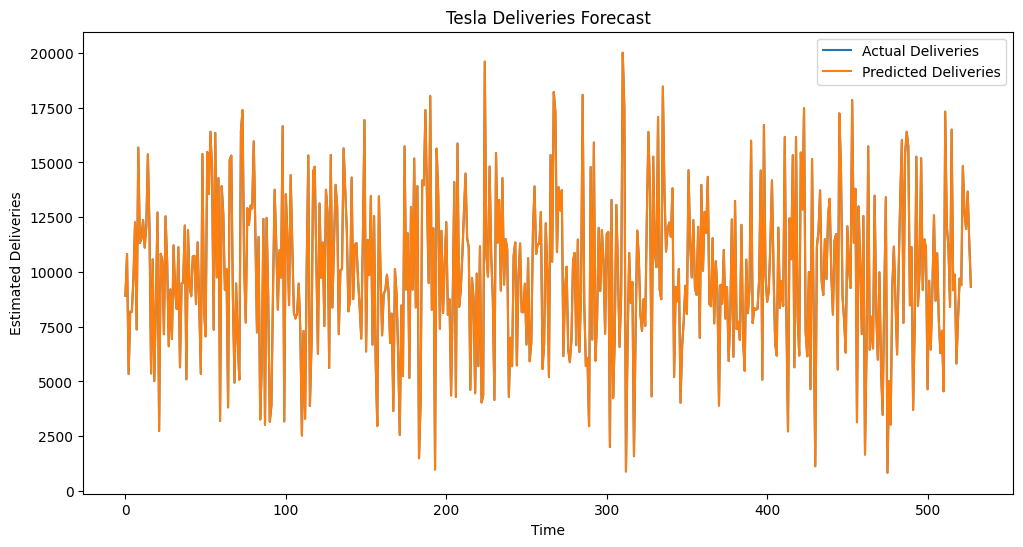

In [81]:
# FORECAST VISUALIZATION


best_pred = ridge_pred

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Deliveries"
)

plt.plot(
    best_pred,
    label="Predicted Deliveries"
)

plt.title("Tesla Deliveries Forecast")
plt.xlabel("Time")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

In [82]:
import joblib

joblib.dump(
    ridge_grid.best_estimator_,
    "tesla_delivery_forecast_model.pkl"
)

print("\nModel Saved Successfully!")


Model Saved Successfully!
